# <font color='#BFD72F' size=6>**0. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import json
from pathlib import Path

import pandas as pd
import requests

# <font color='#BFD72F' size=6>**1. Data Collection**</font> <a class="anchor" id="1"></a>

- 1.1 Save original API response
- 1.2 Extract hourly observations into a DataFrame
- 1.3 Convert the timestamp column into datetime
- 1.4 Sort observations chronologically
- 1.5 historical period: **Year 2023**
- 1.6 Save processed data

[Back to TOC](#toc)

In [2]:
# Define the folders used to store the data.
# parents=True creates any missing parent directories.
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


def fetch_open_meteo_data(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    city_name: str,
) -> pd.DataFrame:
    """Fetch weather data and save raw and processed versions."""

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
        ],
        "timezone": "Europe/Lisbon",
    }

    # Request the data from the API.
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    # --------------------------------------------------
    # 1. RAW LAYER: save the original API response.
    # --------------------------------------------------
    raw_path = RAW_DIR / f"{city_name.lower()}.json"

    with raw_path.open("w", encoding="utf-8") as file:
        json.dump(data, file, ensure_ascii=False, indent=2)

    # --------------------------------------------------
    # 2. PROCESSED LAYER: prepare the analysis table.
    # --------------------------------------------------

    # Extract hourly observations into a DataFrame.
    df = pd.DataFrame(data["hourly"])

    # Convert the timestamp column into datetime objects.
    df["time"] = pd.to_datetime(df["time"])

    # Add the city identifier.
    df["city"] = city_name

    # Rename the variables to simpler column names.
    df.rename(
        columns={
            "temperature_2m": "temperature",
            "relative_humidity_2m": "humidity",
            "wind_speed_10m": "wind_speed",
        },
        inplace=True,
    )

    # Sort observations chronologically.
    df.sort_values(by="time", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Save the processed table separately.
    processed_path = PROCESSED_DIR / f"{city_name.lower()}.csv"
    df.to_csv(processed_path, index=False)

    return df


# Define the historical period.
START_DATE = "2023-01-01"
END_DATE = "2023-12-31"

# Fetch, save, and process the data for both cities.
df_aveiro = fetch_open_meteo_data(
    40.6405, -8.6538, START_DATE, END_DATE, "Aveiro"
)

df_viseu = fetch_open_meteo_data(
    40.6572, -7.9142, START_DATE, END_DATE, "Viseu"
)

# <font color='#BFD72F' size=6>**2. Data Understanding**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

### <font size=6>2.1 Visualization</font> <a class="anchor" id="3.3.4"></a>
  
[Back to TOC](#toc)

In [3]:
df_viseu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           8760 non-null   datetime64[ns]
 1   temperature    8760 non-null   float64       
 2   humidity       8760 non-null   int64         
 3   precipitation  8760 non-null   float64       
 4   wind_speed     8760 non-null   float64       
 5   city           8760 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 410.8+ KB


In [4]:
df_viseu

,time,temperature,humidity,precipitation,wind_speed,city
0,2023-01-01 00:00:00,11.7,91,2.1,18.6,Viseu
1,2023-01-01 01:00:00,11.4,91,1.1,16.4,Viseu
2,2023-01-01 02:00:00,11.7,88,0.6,19.6,Viseu
3,2023-01-01 03:00:00,11.9,86,0.1,20.8,Viseu
4,2023-01-01 04:00:00,12.1,84,0.0,21.7,Viseu
...,...,...,...,...,...,...
8755,2023-12-31 19:00:00,7.8,77,0.0,6.8,Viseu
8756,2023-12-31 20:00:00,6.9,80,0.0,5.6,Viseu
8757,2023-12-31 21:00:00,6.0,85,0.0,7.3,Viseu
8758,2023-12-31 22:00:00,5.4,87,0.0,6.3,Viseu


### <font size=6>2.1 Miising Values</font> <a class="anchor" id="3.3.4"></a>
  
[Back to TOC](#toc)

In [5]:
# 3. Check for duplicate times
duplicates_aveiro = df_aveiro["time"].duplicated().sum()
duplicates_viseu = df_viseu["time"].duplicated().sum()

print(f"Aveiro duplicate times: {duplicates_aveiro}")
print(f"Viseu duplicate time: {duplicates_viseu}")

Aveiro duplicate times: 0
Viseu duplicate time: 0


In [6]:
# Check the number of missing values in each column
print("Missing values - Aveiro:")
print(df_aveiro.isna().sum())

print("\nMissing values - Viseu:")
print(df_viseu.isna().sum())

Missing values - Aveiro:
time             0
temperature      0
humidity         0
precipitation    0
wind_speed       0
city             0
dtype: int64

Missing values - Viseu:
time             0
temperature      0
humidity         0
precipitation    0
wind_speed       0
city             0
dtype: int64


In [7]:
def check_missing_days(df, name):
    # Extract only the calendar date from the timestamp
    dates = df["time"].dt.normalize()

    # Create every calendar day between the first and last observation
    expected_dates = pd.date_range(
        start=dates.min(),
        end=dates.max(),
        freq="D"
    )

    # Find days that are not present in the dataset
    missing_dates = expected_dates.difference(dates)

    print(f"{name}:")
    
    if len(missing_dates) == 0:
        print("No missing days.")
    else:
        print(f"Missing days: {len(missing_dates)}")
        print(missing_dates)


check_missing_days(df_aveiro, "Aveiro")
check_missing_days(df_viseu, "Viseu")

Aveiro:
No missing days.
Viseu:
No missing days.


### <font size=6>2.2 Inconsistencies / Invalid values</font> <a class="anchor" id="3.3.4"></a>

#### make pretty
[Back to TOC](#toc)

In [8]:
# Select the core continuous weather variables
variables = ['temperature', 'humidity', 'precipitation', 'wind_speed']


def get_descriptive_summary(df: pd.DataFrame, city_name: str) -> pd.DataFrame:
  """Calculates Min, Max, Mean, Std, and Quantiles for weather stream variables."""
  stats = df[variables].agg(['min', 'max', 'mean', 'std']).T
  stats.columns = ['Min', 'Max', 'Mean', 'Std']

  # Add 20th and 80th percentiles for warm-up / threshold context
  stats['Q20 (20%)'] = df[variables].quantile(0.20)
  stats['Q50 (Median)'] = df[variables].quantile(0.50)
  stats['Q80 (80%)'] = df[variables].quantile(0.80)

  stats.insert(0, 'City', city_name)
  return stats.round(2)


# Compute for both clean datasets
summary_aveiro = get_descriptive_summary(df_aveiro, 'Aveiro')
summary_viseu = get_descriptive_summary(df_viseu, 'Viseu')

# Combine into one table
full_summary = pd.concat([summary_aveiro, summary_viseu])
print(full_summary)

                 City   Min    Max   Mean    Std  Q20 (20%)  Q50 (Median)  \
temperature    Aveiro   0.1   33.2  15.98   4.93       12.0          16.5   
humidity       Aveiro  21.0  100.0  80.40  15.61       67.0          84.0   
precipitation  Aveiro   0.0   15.5   0.13   0.61        0.0           0.0   
wind_speed     Aveiro   0.0   48.3  13.63   8.10        6.2          12.3   
temperature     Viseu  -2.5   40.2  14.85   7.12        8.8          14.3   
humidity        Viseu  13.0  100.0  72.53  21.50       53.0          77.0   
precipitation   Viseu   0.0   12.7   0.14   0.61        0.0           0.0   
wind_speed      Viseu   0.0   41.3  10.12   6.03        4.8           8.8   

               Q80 (80%)  
temperature         20.0  
humidity            94.0  
precipitation        0.0  
wind_speed          20.2  
temperature         20.8  
humidity            94.0  
precipitation        0.0  
wind_speed          15.4  


## TENTATIVA

PHYSICAL_BOUNDS = {
    "temperature": (-10.0, 50.0),   # °C
    "humidity": (0.0, 100.0),       # %
    "precipitation": (0.0, 150.0),  # mm/h
    "wind_speed": (0.0, 150.0)      # km/h
}

def audit_and_clean_stream(df: pd.DataFrame, city_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Audits physical bounds and handles missing values without removing genuine extreme events.
    """
    df_clean = df.copy()
    audit_logs = []
    
    # Ensure chronology
    df_clean["time"] = pd.to_datetime(df_clean["time"])
    df_clean.sort_values(by="time", inplace=True)
    df_clean.reset_index(drop=True, inplace=True)
    
    # Identify impossible values and set to NaN
    for col, (min_val, max_val) in PHYSICAL_BOUNDS.items():
        invalid_mask = (df_clean[col] < min_val) | (df_clean[col] > max_val)
        invalid_count = invalid_mask.sum()
        if invalid_count > 0:
            audit_logs.append({
                "city": city_name,
                "variable": col,
                "issue": f"Out of physical bounds [{min_val}, {max_val}]",
                "count": invalid_count
            })
            df_clean.loc[invalid_mask, col] = np.nan
            
    # Forward-fill missing/corrupted values to preserve stream temporal order
    df_clean[list(PHYSICAL_BOUNDS.keys())] = df_clean[list(PHYSICAL_BOUNDS.keys())].ffill().bfill()
    
    return df_clean, pd.DataFrame(audit_logs)

df_aveiro_clean, audit_aveiro = audit_and_clean_stream(df_aveiro, "Aveiro")
df_viseu_clean, audit_viseu = audit_and_clean_stream(df_viseu, "Viseu")

#audit_summary = pd.concat([audit_aveiro, audit_viseu], ignore_index=True)
#audit_summary.to_csv("data/data_quality_audit.csv", index=False)


## Voltar ao trabalho

In [ ]:
# 1. Define warm-up length (first 15% of the data)
WARMUP_PERCENTAGE = 0.15
warmup_len = int(len(df_aveiro) * WARMUP_PERCENTAGE)

# 2. Pool warm-up temperature data from both cities
pooled_warmup_temp = pd.concat(
    [df_aveiro["temperature"].iloc[:warmup_len], df_viseu["temperature"].iloc[:warmup_len]]
)

# 3. Calculate and freeze the 80th percentile threshold (tau_T_hot)
TAU_T_HOT = float(pooled_warmup_temp.quantile(0.80))

print(f"TAU_T_HOT is now defined: {TAU_T_HOT:.2f} °C")

In [ ]:
# Defined strictly on current temperature and the frozen threshold
df_aveiro["target"] = (df_aveiro["temperature"] >= TAU_T_HOT).astype(int)
df_viseu["target"] = (df_viseu["temperature"] >= TAU_T_HOT).astype(int)

1. Fetching raw streams from Open-Meteo...

Data quality audit - Aveiro:
Empty DataFrame
Columns: []
Index: []

Data quality audit - Viseu:
Empty DataFrame
Columns: []
Index: []

2. Frozen Target Threshold (tau_T_hot): 12.90 °C

3. Tracking sliding performance for Aveiro (Representation B)...


C:\Users\wwwnj\AppData\Local\Temp\ipykernel_40500\2869224368.py:373: DeprecationWarning: Passing an instance to utils.Rolling is deprecated and will be removed in a future release. Pass the class and forward constructor kwargs instead, e.g. utils.Rolling(stats.Mean, window_size=...) or utils.Rolling(stats.Var, window_size=..., ddof=0).
  name: utils.Rolling(


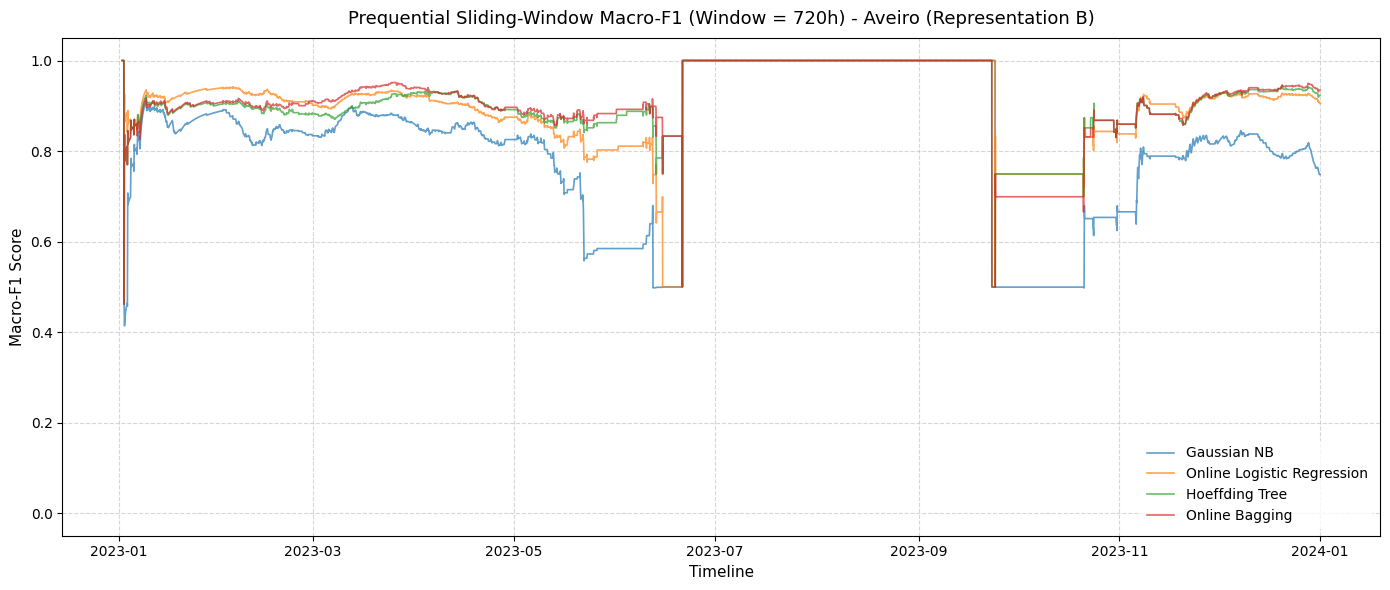


4. Tracking sliding performance for Viseu (Representation B)...


C:\Users\wwwnj\AppData\Local\Temp\ipykernel_40500\2869224368.py:373: DeprecationWarning: Passing an instance to utils.Rolling is deprecated and will be removed in a future release. Pass the class and forward constructor kwargs instead, e.g. utils.Rolling(stats.Mean, window_size=...) or utils.Rolling(stats.Var, window_size=..., ddof=0).
  name: utils.Rolling(


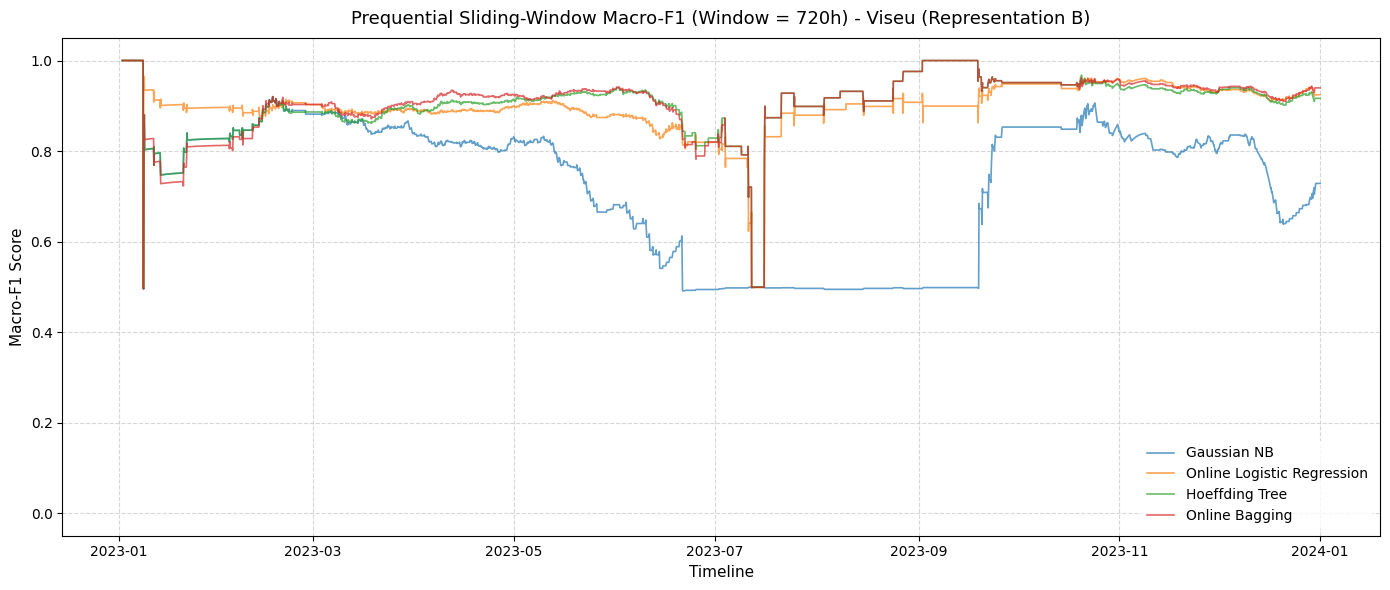


Final Macro-F1 scores - Aveiro:
Gaussian NB                   0.748165
Online Logistic Regression    0.904842
Hoeffding Tree                0.923032
Online Bagging                0.934778
Name: 8735, dtype: float64

Final Macro-F1 scores - Viseu:
Gaussian NB                   0.728481
Online Logistic Regression    0.924353
Hoeffding Tree                0.916390
Online Bagging                0.939500
Name: 8735, dtype: float64


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from river import (
    compose,
    ensemble,
    linear_model,
    metrics,
    naive_bayes,
    tree,
    utils,
)


# ==============================================================================
# 1. FETCH RAW DATA FROM OPEN-METEO API
# ==============================================================================

def fetch_open_meteo_data(
    latitude: float,
    longitude: float,
    start_date: str,
    end_date: str,
    city_name: str,
) -> pd.DataFrame:
    """Fetches historical hourly weather data for a given city from Open-Meteo API."""

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
        ],
        "timezone": "Europe/Lisbon",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    data = response.json()

    df = pd.DataFrame(data["hourly"])

    df["time"] = pd.to_datetime(df["time"])
    df["city"] = city_name

    df.rename(
        columns={
            "temperature_2m": "temperature",
            "relative_humidity_2m": "humidity",
            "precipitation": "precipitation",
            "wind_speed_10m": "wind_speed",
        },
        inplace=True,
    )

    df.sort_values(by="time", inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


START_DATE = "2023-01-01"
END_DATE = "2023-12-31"


print("1. Fetching raw streams from Open-Meteo...")

df_aveiro_raw = fetch_open_meteo_data(
    40.6405,
    -8.6538,
    START_DATE,
    END_DATE,
    "Aveiro",
)

df_viseu_raw = fetch_open_meteo_data(
    40.6572,
    -7.9142,
    START_DATE,
    END_DATE,
    "Viseu",
)


# ==============================================================================
# 2. AUDIT & IMPUTE DATA QUALITY
# ==============================================================================

PHYSICAL_BOUNDS = {
    "temperature": (-10.0, 50.0),
    "humidity": (0.0, 100.0),
    "precipitation": (0.0, 150.0),
    "wind_speed": (0.0, 150.0),
}


def audit_and_clean_stream(
    df: pd.DataFrame,
    city_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    df_clean = df.copy()
    audit_logs = []

    df_clean["time"] = pd.to_datetime(df_clean["time"])

    df_clean.sort_values(
        by="time",
        inplace=True,
    )

    df_clean.reset_index(
        drop=True,
        inplace=True,
    )

    for col, (min_val, max_val) in PHYSICAL_BOUNDS.items():

        invalid_mask = (
            (df_clean[col] < min_val)
            | (df_clean[col] > max_val)
        )

        invalid_count = invalid_mask.sum()

        if invalid_count > 0:

            audit_logs.append(
                {
                    "city": city_name,
                    "variable": col,
                    "issue": (
                        f"Out of bounds "
                        f"[{min_val}, {max_val}]"
                    ),
                    "count": invalid_count,
                }
            )

            df_clean.loc[
                invalid_mask,
                col,
            ] = np.nan

    weather_columns = list(PHYSICAL_BOUNDS.keys())

    df_clean[weather_columns] = (
        df_clean[weather_columns]
        .ffill()
        .bfill()
    )

    return (
        df_clean,
        pd.DataFrame(audit_logs),
    )


df_aveiro_clean, aveiro_audit = audit_and_clean_stream(
    df_aveiro_raw,
    "Aveiro",
)

df_viseu_clean, viseu_audit = audit_and_clean_stream(
    df_viseu_raw,
    "Viseu",
)


# Optional: display audit results

print("\nData quality audit - Aveiro:")
print(aveiro_audit)

print("\nData quality audit - Viseu:")
print(viseu_audit)


# ==============================================================================
# 3. WARM-UP THRESHOLD & FEATURE REPRESENTATIONS
# ==============================================================================

WARMUP_PERCENTAGE = 0.15

warmup_len = int(
    len(df_aveiro_clean) * WARMUP_PERCENTAGE
)


pooled_warmup_temp = pd.concat(
    [
        df_aveiro_clean["temperature"].iloc[:warmup_len],
        df_viseu_clean["temperature"].iloc[:warmup_len],
    ]
)


TAU_T_HOT = float(
    pooled_warmup_temp.quantile(0.80)
)


print(
    f"\n2. Frozen Target Threshold "
    f"(tau_T_hot): {TAU_T_HOT:.2f} °C"
)


def prepare_stream_features(
    df: pd.DataFrame,
    tau_threshold: float,
) -> pd.DataFrame:

    df_feat = df.copy()

    # --------------------------------------------------------------------------
    # Target T2
    # --------------------------------------------------------------------------

    df_feat["target"] = (
        df_feat["temperature"] >= tau_threshold
    ).astype(int)

    # --------------------------------------------------------------------------
    # Representation A: Lagged variables (t-1)
    # --------------------------------------------------------------------------

    df_feat["temp_lag1"] = (
        df_feat["temperature"].shift(1)
    )

    df_feat["humidity_lag1"] = (
        df_feat["humidity"].shift(1)
    )

    df_feat["precipitation_lag1"] = (
        df_feat["precipitation"].shift(1)
    )

    df_feat["wind_speed_lag1"] = (
        df_feat["wind_speed"].shift(1)
    )

    # --------------------------------------------------------------------------
    # Representation B: Stream-aware aggregations
    # --------------------------------------------------------------------------

    df_feat["delta_temp"] = (
        df_feat["temp_lag1"]
        - df_feat["temperature"].shift(2)
    )

    df_feat["rolling_mean_temp_6h"] = (
        df_feat["temp_lag1"]
        .rolling(window=6)
        .mean()
    )

    df_feat["rolling_std_temp_6h"] = (
        df_feat["temp_lag1"]
        .rolling(window=6)
        .std()
        .fillna(0)
    )

    df_feat["rolling_mean_temp_24h"] = (
        df_feat["temp_lag1"]
        .rolling(window=24)
        .mean()
    )

    lagged_heat_events = (
        df_feat["temp_lag1"] >= tau_threshold
    ).astype(int)

    df_feat["heat_events_last_24h"] = (
        lagged_heat_events
        .rolling(window=24)
        .sum()
    )

    # Remove rows containing NaN values created by lagging/rolling windows

    df_feat.dropna(
        inplace=True
    )

    df_feat.reset_index(
        drop=True,
        inplace=True,
    )

    return df_feat


# ------------------------------------------------------------------------------
# Define feature streams
# ------------------------------------------------------------------------------

df_aveiro_stream = prepare_stream_features(
    df_aveiro_clean,
    TAU_T_HOT,
)

df_viseu_stream = prepare_stream_features(
    df_viseu_clean,
    TAU_T_HOT,
)


FEATURE_COLS_A = [
    "temp_lag1",
    "humidity_lag1",
    "precipitation_lag1",
    "wind_speed_lag1",
]


FEATURE_COLS_B = FEATURE_COLS_A + [
    "delta_temp",
    "rolling_mean_temp_6h",
    "rolling_std_temp_6h",
    "rolling_mean_temp_24h",
    "heat_events_last_24h",
]


# ==============================================================================
# 4. PREQUENTIAL SLIDING-WINDOW EVALUATION & DRIFT PLOTS
# ==============================================================================

WINDOW_SIZE = 720  # 30-day sliding window (720 hours)


def track_sliding_performance(
    df_stream: pd.DataFrame,
    feature_cols: list[str],
) -> pd.DataFrame:

    # --------------------------------------------------------------------------
    # Define online learning models
    # --------------------------------------------------------------------------

    models = {
        "Gaussian NB": naive_bayes.GaussianNB(),

        "Online Logistic Regression": compose.Pipeline(
            linear_model.LogisticRegression()
        ),

        "Hoeffding Tree": tree.HoeffdingTreeClassifier(),

        "Online Bagging": ensemble.BaggingClassifier(
        model=tree.HoeffdingTreeClassifier(),
        seed=42,),
    }

    # --------------------------------------------------------------------------
    # Sliding-window Macro-F1 evaluators
    # --------------------------------------------------------------------------

    sliding_evaluators = {
        name: utils.Rolling(
            metrics.MacroF1(),
            window_size=WINDOW_SIZE,
        )
        for name in models
    }

    history = []

    # --------------------------------------------------------------------------
    # Prequential evaluation
    # --------------------------------------------------------------------------

    for idx, row in df_stream.iterrows():

        x = row[
            feature_cols
        ].to_dict()

        y = int(
            row["target"]
        )

        timestamp = (
            row["time"]
            if "time" in row
            else idx
        )

        row_history = {
            "time": timestamp
        }

        # ----------------------------------------------------------------------
        # Predict -> evaluate -> learn
        # ----------------------------------------------------------------------

        for name, model in models.items():

            y_pred = model.predict_one(x)

            if y_pred is not None:

                sliding_evaluators[name].update(
                    y,
                    y_pred,
                )

                row_history[name] = (
                    sliding_evaluators[name].get()
                )

            else:

                row_history[name] = None

            # Learn only AFTER prediction
            model.learn_one(
                x,
                y,
            )

        history.append(
            row_history
        )

    return pd.DataFrame(
        history
    )


# ==============================================================================
# 5. PLOT PREQUENTIAL DRIFT
# ==============================================================================

def plot_prequential_drift(
    df_history: pd.DataFrame,
    title: str,
):

    plt.figure(
        figsize=(14, 6)
    )

    model_names = [
        col
        for col in df_history.columns
        if col != "time"
    ]

    for name in model_names:

        plt.plot(
            df_history["time"],
            df_history[name],
            label=name,
            linewidth=(
                1.8
                if "Adaptive" in name
                else 1.2
            ),
            alpha=(
                0.9
                if "Adaptive" in name
                else 0.7
            ),
        )

    plt.title(
        (
            "Prequential Sliding-Window "
            f"Macro-F1 (Window = {WINDOW_SIZE}h) "
            f"- {title}"
        ),
        fontsize=13,
        pad=10,
    )

    plt.xlabel(
        "Timeline",
        fontsize=11,
    )

    plt.ylabel(
        "Macro-F1 Score",
        fontsize=11,
    )

    plt.ylim(
        -0.05,
        1.05,
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5,
    )

    plt.legend(
        loc="lower right",
        frameon=True,
        facecolor="white",
        edgecolor="none",
    )

    plt.tight_layout()

    plt.show()


# ==============================================================================
# 6. RUN AND VISUALIZE
# ==============================================================================

print(
    "\n3. Tracking sliding performance "
    "for Aveiro (Representation B)..."
)

history_aveiro_b = track_sliding_performance(
    df_aveiro_stream,
    FEATURE_COLS_B,
)

plot_prequential_drift(
    history_aveiro_b,
    "Aveiro (Representation B)",
)


print(
    "\n4. Tracking sliding performance "
    "for Viseu (Representation B)..."
)

history_viseu_b = track_sliding_performance(
    df_viseu_stream,
    FEATURE_COLS_B,
)

plot_prequential_drift(
    history_viseu_b,
    "Viseu (Representation B)",
)


# ==============================================================================
# 7. OPTIONAL: FINAL PERFORMANCE SUMMARY
# ==============================================================================

print("\nFinal Macro-F1 scores - Aveiro:")

print(
    history_aveiro_b.drop(
        columns=["time"]
    ).iloc[-1]
)


print("\nFinal Macro-F1 scores - Viseu:")

print(
    history_viseu_b.drop(
        columns=["time"]
    ).iloc[-1]
)

